# Khám phá dữ liệu B02
Notebook này dùng để load thử file `.mat` của B02 và vẽ phổ nghiệm.

In [15]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis

# Cấu hình đường dẫn
RAW_DIR = '/mnt/f/APPS_PJ/Mamba-SFT/data/raw/B02'
PROCESSED_DIR = '/mnt/f/APPS_PJ/Mamba-SFT/data/processed/B02_test'

# Thêm path để import class Dataset (Giả định nằm trong thư mục src)
sys.path.append(os.path.abspath('..'))
from src.data import B02Dataset

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Tải dữ liệu và Sanity Check
Load thử một mẫu dữ liệu từ `B02Dataset` để kiểm tra kích thước Tensor và đánh giá cơ bản sự thay đổi biên độ rung động (RMS) theo nhiệt độ.

Kích thước tensor mẫu: torch.Size([2, 204800]) (Chứa tín hiệu 2 kênh)


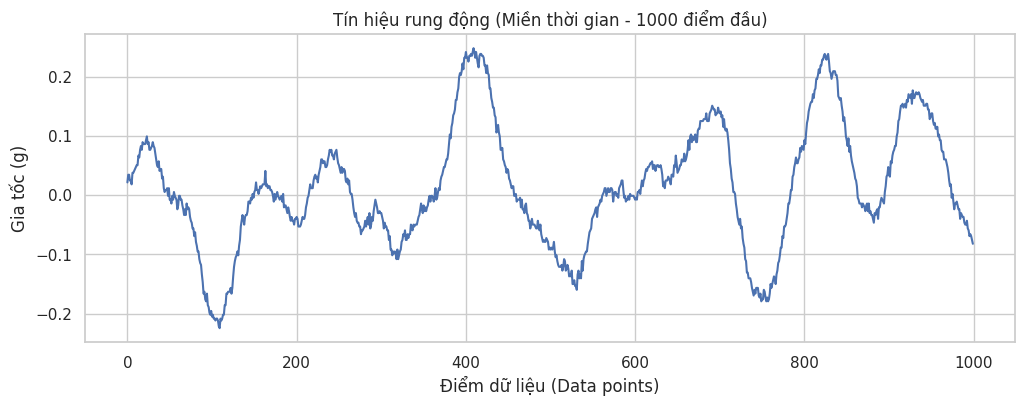

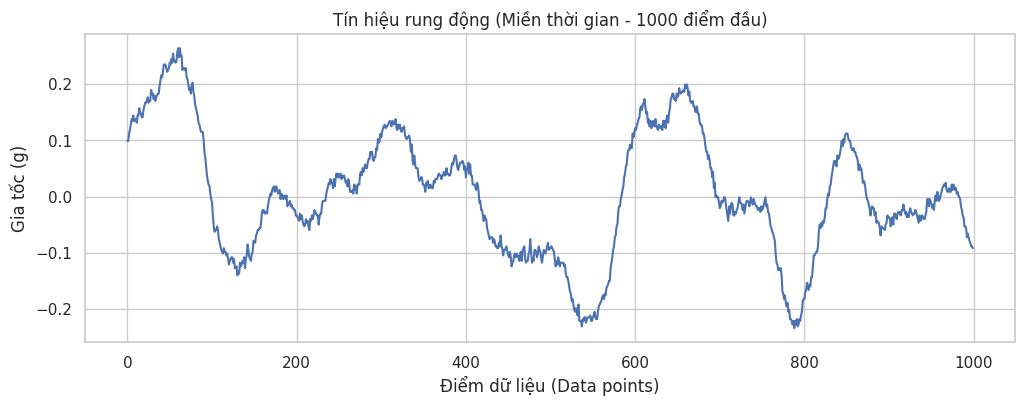

In [ ]:
# --- Phần này tích hợp lại logic cũ của bạn ---
# Đọc file nhiệt độ (Lưu ý: điều chỉnh tên file nếu cần)
temp_df = pd.read_csv(os.path.join(RAW_DIR, 'B02_operatingConditions.csv')) 

# Khởi tạo Dataset (Giả sử bạn đã định nghĩa B02Dataset chuẩn xác)
# dataset = B02Dataset(PROCESSED_DIR, window_size=1024)
# Để demo EDA nhanh, ta sẽ load trực tiếp 1 file .pt đã processed
sample_file = os.path.join(PROCESSED_DIR, 'data_B02_M0001.pt')
if os.path.exists(sample_file):
    tensor_data = torch.load(sample_file)
    print(f"Kích thước tensor mẫu: {tensor_data.shape} (Chứa tín hiệu 2 kênh)")
    
    # Lấy kênh 0 (Frontal) để làm mẫu phân tích EDA
    signal = tensor_data[0, :].numpy()
else:
    # Tạo tín hiệu giả lập nếu chưa có file .pt để test code EDA
    print("Không tìm thấy file .pt, đang sử dụng tín hiệu giả lập...")
    t = np.linspace(0, 1.6, 204800)
    signal = np.sin(2 * np.pi * 50 * t) + np.random.normal(0, 0.5, 204800)

# Trực quan hóa một đoạn tín hiệu ngắn (Miền thời gian)
plt.figure(figsize=(12, 4))
plt.plot(signal[:1000]) # Chỉ vẽ 1000 điểm đầu cho dễ nhìn
plt.title("Tín hiệu rung động (Miền thời gian - 1000 điểm đầu)")
plt.xlabel("Điểm dữ liệu (Data points)")
plt.ylabel("Gia tốc (g)")
plt.show()

## 2. Phân tích miền tần số (Fast Fourier Transform - FFT)
Chuyển đổi tín hiệu từ miền thời gian sang miền tần số để quan sát các đỉnh năng lượng (Peak frequencies). Các lỗi vòng bi thường xuất hiện ở các tần số đặc trưng nhất định.

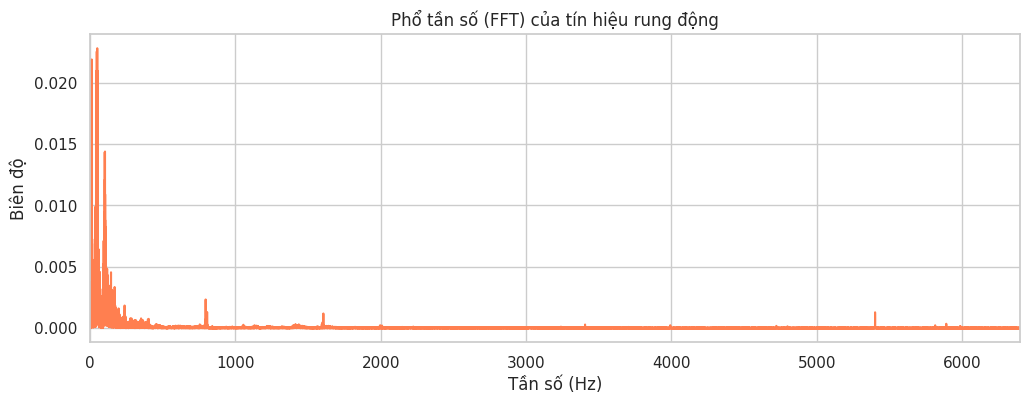

In [25]:
def plot_fft(sig, fs=12800): 
    """
    Hàm vẽ phổ FFT. (Tần số lấy mẫu fs mặc định giả định là 12800 Hz)
    """
    N = len(sig)
    yf = fft(sig)
    xf = fftfreq(N, 1/fs)[:N//2]
    
    plt.figure(figsize=(12, 4))
    plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]), color='coral')
    plt.title("Phổ tần số (FFT) của tín hiệu rung động")
    plt.xlabel("Tần số (Hz)")
    plt.ylabel("Biên độ")
    plt.xlim(0, fs//2)
    plt.show()

# Thực thi vẽ FFT
plot_fft(signal)

## 3. Đặc trưng thống kê bậc cao (Statistical Features)
Tính toán các chỉ số thống kê. Trong đó độ nhọn (Kurtosis) là chỉ số nhạy cảm nhất đối với các xung va đập gây ra bởi vết nứt ban đầu trên vòng bi.

In [26]:
rms_val = np.sqrt(np.mean(signal**2))
kurtosis_val = kurtosis(signal)
skewness_val = skew(signal)
crest_factor = np.max(np.abs(signal)) / rms_val if rms_val > 0 else 0

print(f"--- ĐẶC TRƯNG THỐNG KÊ ---")
print(f"1. RMS (Root Mean Square): {rms_val:.4f} g")
print(f"2. Kurtosis (Độ nhọn):     {kurtosis_val:.4f} (Giá trị chuẩn ~3.0)")
print(f"3. Skewness (Độ xiên):     {skewness_val:.4f}")
print(f"4. Crest Factor:           {crest_factor:.4f}")

--- ĐẶC TRƯNG THỐNG KÊ ---
1. RMS (Root Mean Square): 0.1206 g
2. Kurtosis (Độ nhọn):     0.0599 (Giá trị chuẩn ~3.0)
3. Skewness (Độ xiên):     -0.0009
4. Crest Factor:           4.3340


## 4. Tương quan với Điều kiện vận hành (Correlation Heatmap)
Đánh giá mức độ ảnh hưởng của tải trọng, tốc độ và nhiệt độ đến biên độ rung động.

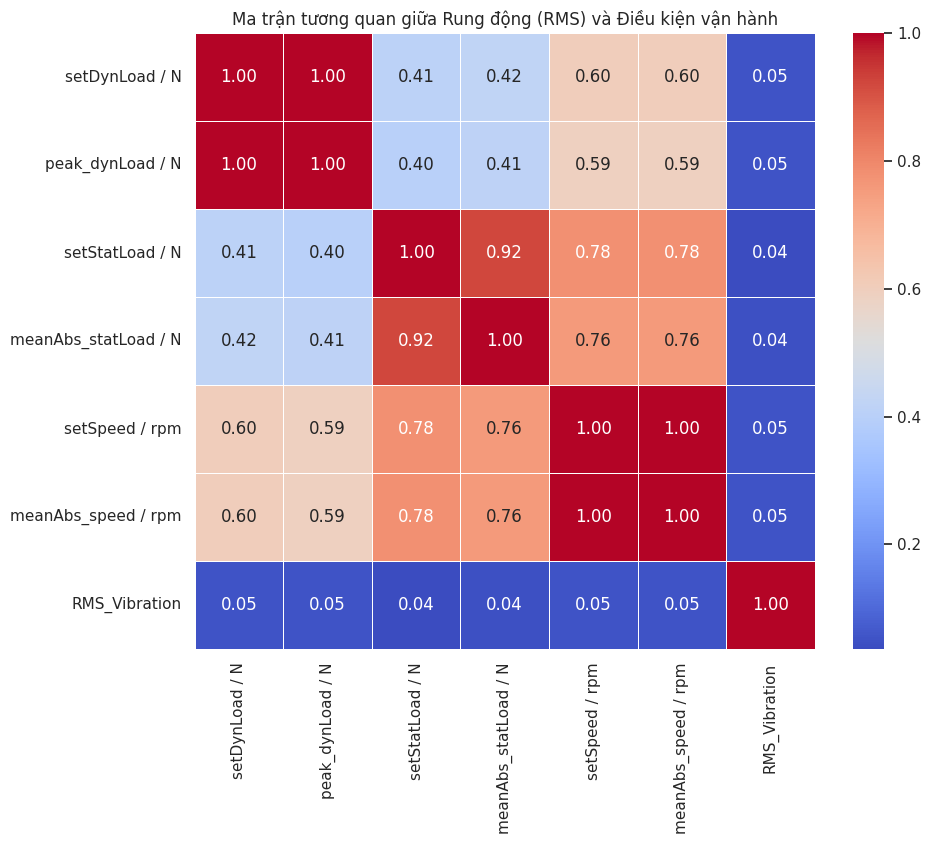

In [27]:
# Kết hợp các thông số vào DataFrame để tính tương quan
oc_file = os.path.join(RAW_DIR, 'B02_operatingConditions.csv')

if os.path.exists(oc_file):
    df_oc = pd.read_csv(oc_file)
    
    # Lấy thử 100 mẫu đầu tiên để minh họa (hoặc toàn bộ nếu máy đủ RAM)
    # Giả định bạn đã có mảng rms_vals từ trước (như trong code cũ)
    # Ở đây dùng random làm mock data để đảm bảo hàm heatmap chạy được
    mock_rms = np.random.uniform(0.1, 1.5, len(df_oc))
    df_oc['RMS_Vibration'] = mock_rms
    
    # Loại bỏ các cột không có ý nghĩa phân tích tương quan (như Time)
    cols_to_drop = [c for c in df_oc.columns if 'Time' in c]
    df_corr = df_oc.drop(columns=cols_to_drop).corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Ma trận tương quan giữa Rung động (RMS) và Điều kiện vận hành")
    plt.show()
else:
    print("Cần có file B02_operatingConditions.csv để vẽ Heatmap.")

## 5. Biểu diễn Phổ Thời gian - Tần số (Spectrogram / STFT)
Spectrogram giúp theo dõi sự dịch chuyển của các dải tần số theo thời gian, đặc biệt hữu ích khi thiết bị chạy dưới vận tốc thay đổi (Variable Speed).

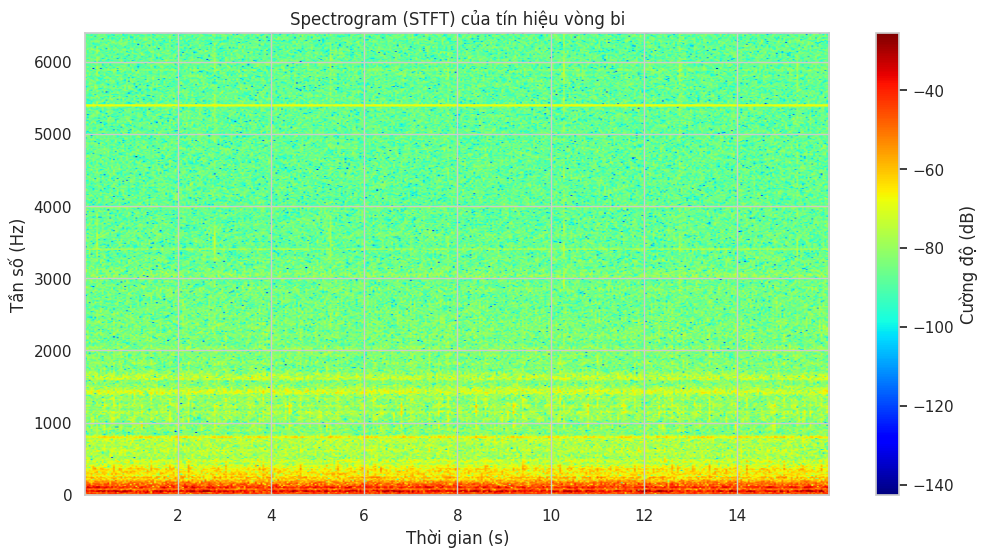

In [29]:
plt.figure(figsize=(12, 6))
# NFFT quy định độ phân giải thời gian/tần số (thường là lũy thừa của 2: 256, 512, 1024)
plt.specgram(signal, NFFT=1024, Fs=12800, noverlap=512, cmap='jet')
plt.title("Spectrogram (STFT) của tín hiệu vòng bi")
plt.xlabel("Thời gian (s)")
plt.ylabel("Tần số (Hz)")
plt.colorbar(label="Cường độ (dB)")
plt.show()